# Cdk2 and Cdk4 Reporters Activity Quantification

This notebook demonstrates the process of segmenting nuclei and analyzing Cdk2 and Cdk4/6 activity based of fluorescence reporters at the single-cell level in fluorescence microscopy images. 

Although our example dataset contains cells expressing Cdk2 and Cdk4/6 reporters, this notebook can be used to assess nucleus-cytoplasm translocation of any protein that shows a homogenous labeling throughout the nucleus and cytoplasm and also to analyse cells expressing Kinase Translocation Reporters (KTR) and similar sensors.

----

## How We Measure Cdk Activity

We calculate the ratio of mean fluorescence intensity in the cytoplasm versus the nucleus (**cytoplasm/nucleus ratio**) for each cell. 

**Reporter translocation mechanism:**  
Each reporter's translocation is mediated by phosphorylation:
- DHB-Venus by Cdk2 [2]
- mCherry-KTR by Cdk4 [3]

**Interpretation:**
- Higher ratio (> 1) → **more kinase activity**
- Lower ratio (< 1) → **less kinase activity**

> **Note:** The EpH4 cells used in the example dataset have undetectable levels of Cdk6. Furthermore, measuring Cdk4/ activity requires an additional correction factor based on Cdk2 activity to account for cross-reactivity.


#### References

[1] Cambuim, L. O., & Bruni-Cardoso, A. Microscopy image dataset of Cdk2 and Cdk4 activity reporters, phase contrast and histone H2B paired with nuclear masks of  EpH4 mammary epithelial cells across variable cell densities and Cdk inhibition treatments. 10.5281/zenodo.19500864

[2] Spencer, S. L., Cappell, S. D., Tsai, F. C., Overton, K. W., Wang, C. L., & Meyer, T. (2013). The proliferation-quiescence decision is controlled by a bifurcation in CDK2 activity at mitotic exit. *Cell*, 155(2), 369-383. https://doi.org/10.1016/j.cell.2013.08.062 

[3] Yang, H. W., Cappell, S. D., Jaimovich, A., Liu, C., Chung, M., Daigh, L. H., Pack, L. R., Fan, Y., Regot, S., Covert, M., & Meyer, T. (2020). Stress-mediated exit to quiescence restricted by increasing persistence in CDK4/6 activation. *eLife*, 9, e44571. https://doi.org/10.7554/eLife.44571

---

## Workflow Rationale
The figure below illustrates our analysis strategy:

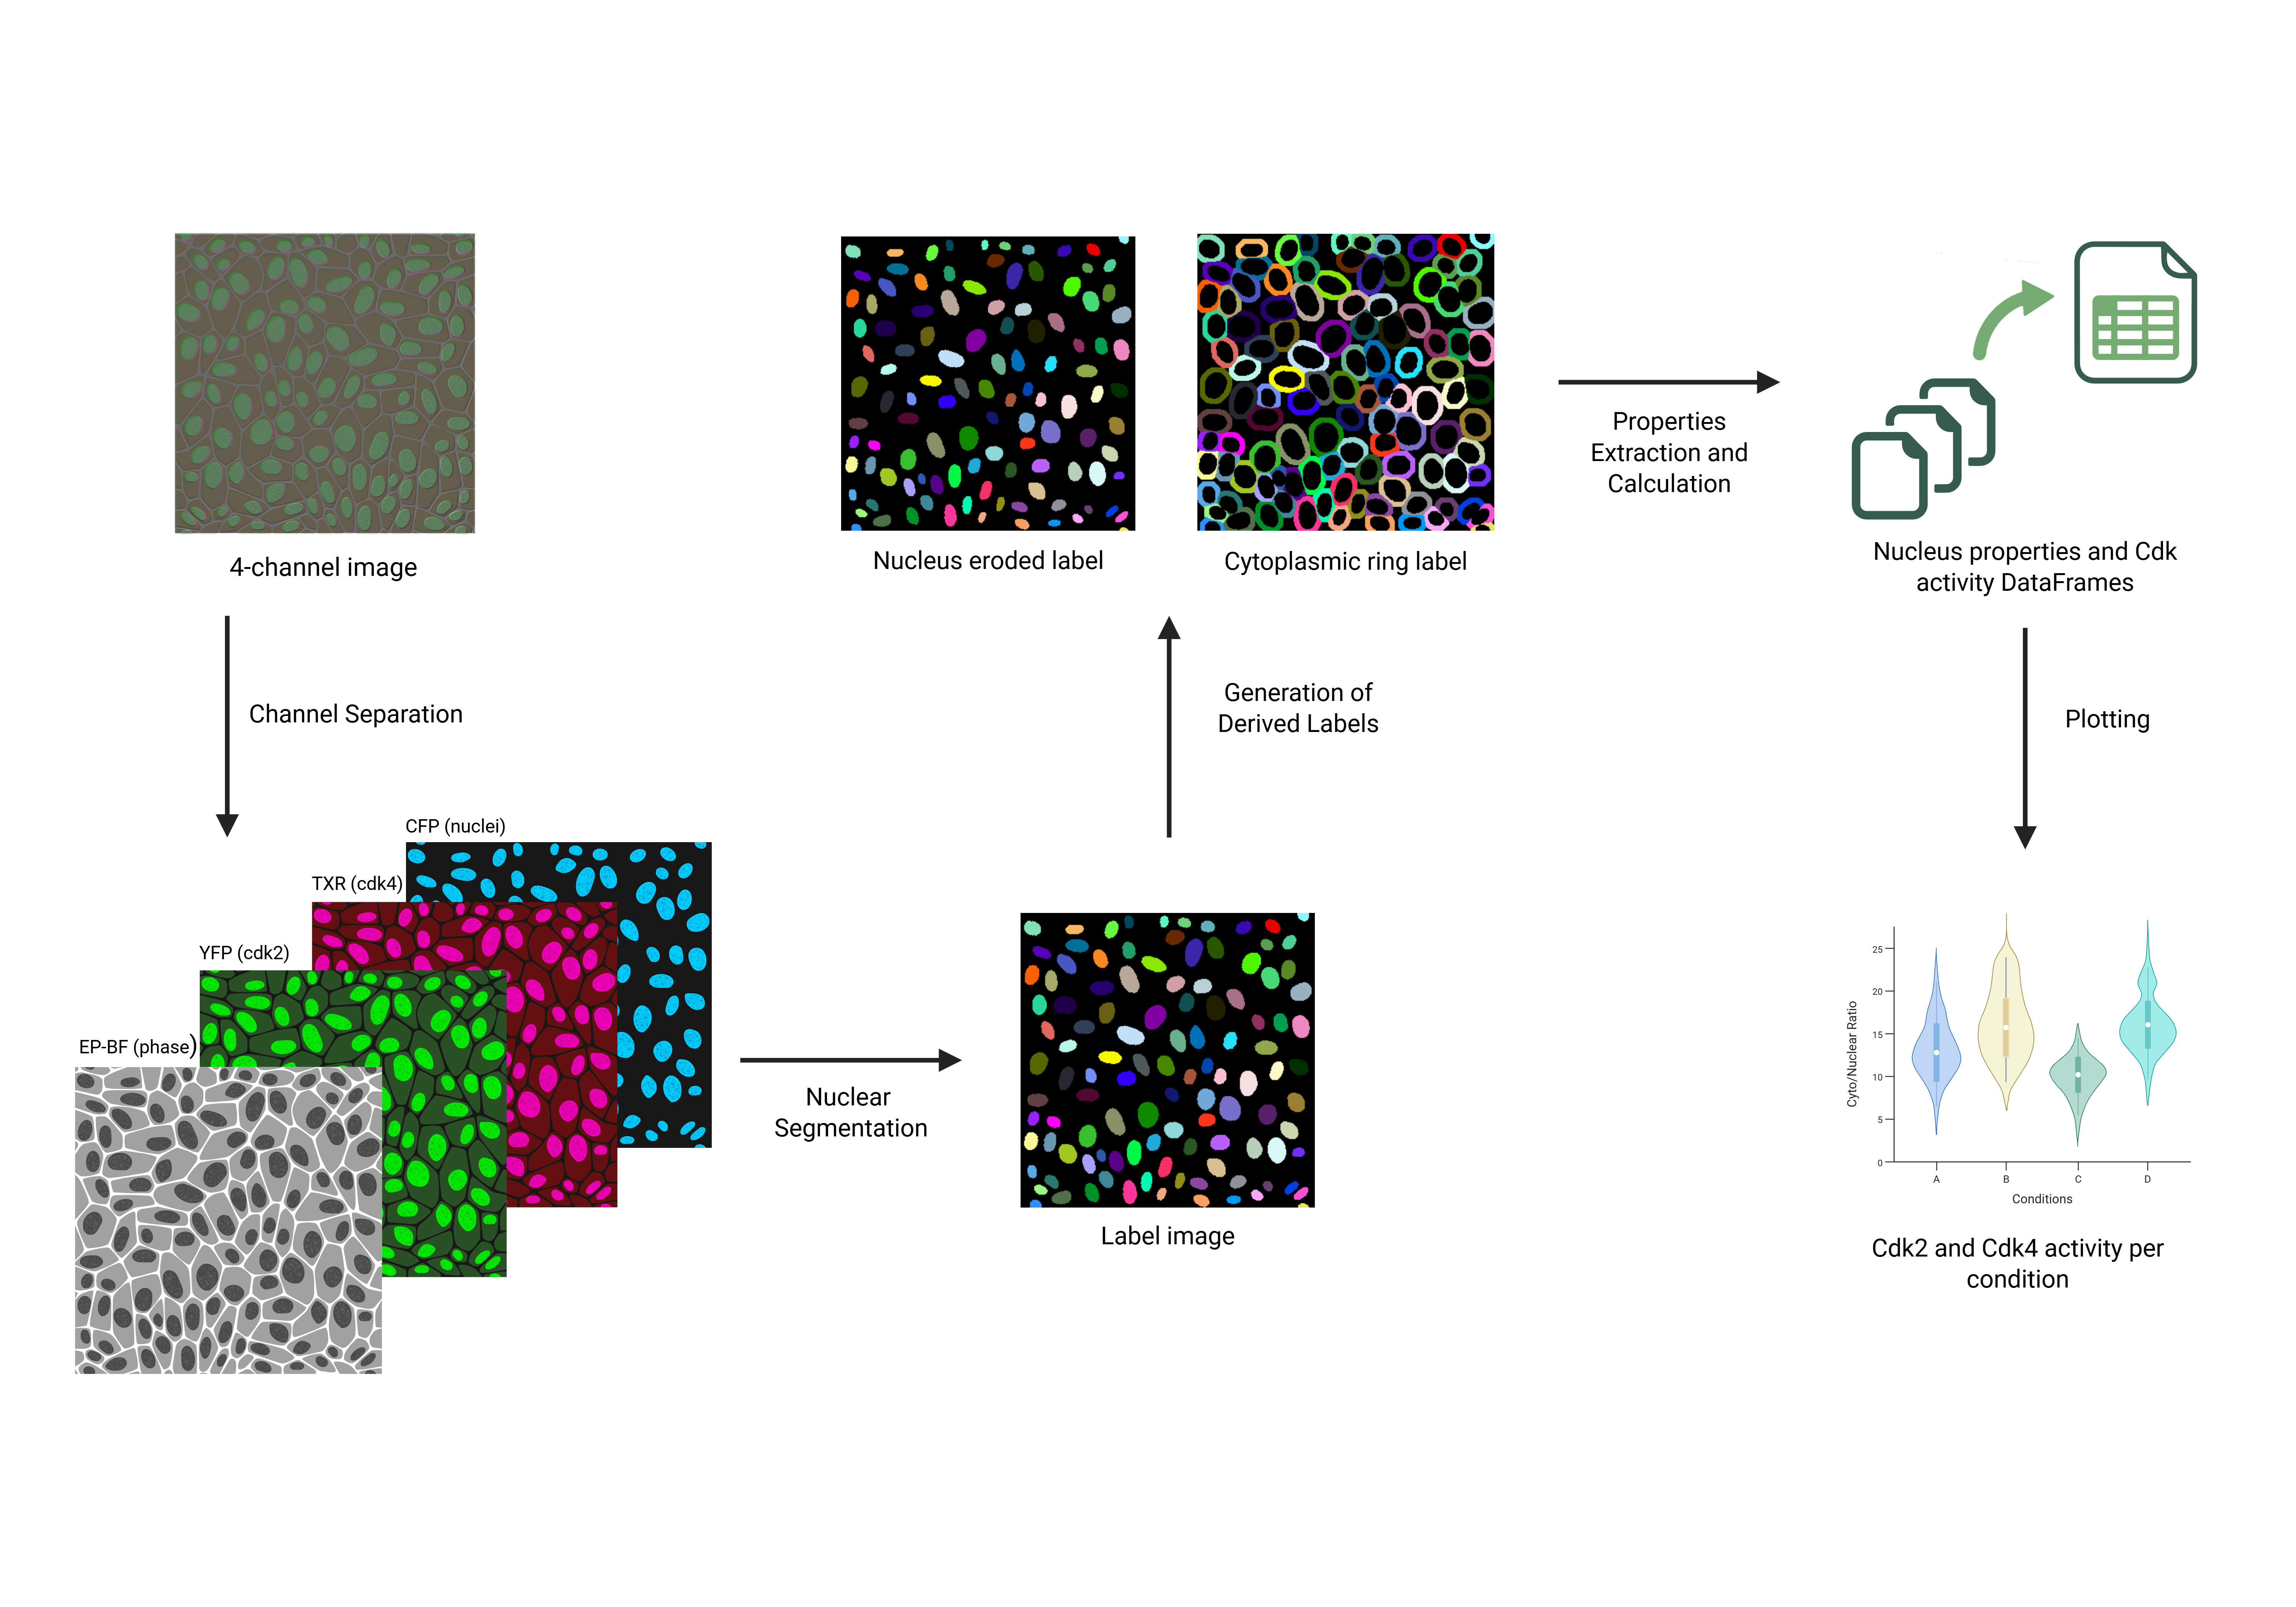

*Figure 1: Overview of the image analysis workflow. Channel are separated, nuclei are segmented, derived labels are generated, fluorescence is quantified in nuclear and cytoplasmic regions, and activity ratios are calculated for each reporter.* 
Created in  https://BioRender.com

---

## Activity Calculations  - Cdk4 activity calculation was established for EpH4 cells based on the Elife paper[2] where the reporter was developed.

##### $\text{Reporter activity} = \frac{\text{Cytoplasmic fluorescence}}{\text{Nuclear fluorescence}}$

$\text{Cdk2 activity} = {\text{Cdk2 reporter activity}}$

$\text{Cdk4 activity} = \text{Cdk4 reporter activity} - 0.35 \times \text{Cdk2 reporter activity}$

---

## Summary

The cells below perform the following steps: 
1. Setup 
2. Channel Separation
3. Nuclear Segmentation
4. Generation of Derived Labels
5. Properties Extraction and Calculation
6. Plotting
---

## 1. Setup

Let's start by importing the necessary libraries and defining the work directory that contains the folder with your image files. Make sure you have all packages installed. We recommend creating a conda environment.

#### Importing libraries
**No actions are required** to import the necessary libraries (no need to change the code).

In [ ]:
# Importing libraries
from pathlib import Path
import os
import glob
import napari
import matplotlib
import matplotlib.pyplot as plt
from skimage.io import imread, imshow, imsave 
from skimage import filters
import pandas as pd
import re
import seaborn as sns
import numpy as np
from skimage import measure
import glob
from stardist.models import StarDist2D
from stardist.plot import render_label
from csbdeep.utils import normalize
from skimage import morphology
import pyclesperanto_prototype as cle  
from scipy.stats import gaussian_kde

#### Defining the work directory

**Action required!:** Update the path below  to your local data directory

> **Note:** This directory must contain your image  tiff files. All other necessary folders will be automatically created here.

In [ ]:
directory_path = "Dataset_Zenodo\Dataset_Zenodo"
# Example (Windows): "C:Users/Name/Documents/"

In [ ]:
# Defining the work directory 
os.chdir(directory_path)
os.getcwd()

> **Important:** It isn't necessary to run the entire notebook at once - you can run sections individually as needed. However, every time you close this notebook and open it again, you must run this Setup section, regardless of which other sections you plan to run. This ensures all required libraries are imported and that you are working in the right directory!


---

## 2. Channel Separation

If your images have not been separated into different channels, you need to separate and save each image channel before starting any processing.

First, we create a folder to store the separated channel. This folder will be named `separate_channels_tiff`, and will be created inside your working directory.

**Action required!:** Update the folder name (in red) below to match your image folder. You don't need to write the full path, just the folder name followed by "/".

In [ ]:
# Creating a folder in your working directory
!mkdir separate_channels_tiff

In [ ]:
# Defining the image folder path
input_folder = 'tiff_files/'

In [ ]:
# Loading and sorting all image paths. In our example, all files are TIFF files. 
image_files =  np.sort(glob.glob(input_folder + '/*.tiff'))
image_files
# This allows us to check which files were found before processing. 
# By running this cell, you expect to see an array with all the names of your images.

Then, we can separate and save each channel in `separate_channels_tiff` folder.

**No actions are required below.** 

In [ ]:
# Separating and saving each channel. Our example images have four channels (phase contrast, CDK2 probe, CDK4 probe, nuclei)
output_folder = 'separate_channels_tiff/'
for i in image_files:
    image = imread(i)
    phase = image[:,:,0]
    cdk2 = image[:,:,1]
    cdk4 = image[:,:,2]
    nuclei = image[:,:,3]
    imsave(os.path.join(output_folder,"phase_"+ f"{os.path.splitext(os.path.basename(i))[0]}.tiff"), phase)
    imsave(os.path.join(output_folder,"cdk2_"+ f"{os.path.splitext(os.path.basename(i))[0]}.tiff"), cdk2)
    imsave(os.path.join(output_folder,"cdk4_"+ f"{os.path.splitext(os.path.basename(i))[0]}.tiff"), cdk4)
    imsave(os.path.join(output_folder,"nuclei_"+ f"{os.path.splitext(os.path.basename(i))[0]}.tiff"), nuclei)

> **Note:** You can verify if the code ran successfully by checking the output above or by manually inspecting the created folder in your file explorer.

---

## 3. Nuclear Segmentation

**Segmentation** identifies and outline individual nuclei from the background and from each other in microscopy images. Each segmented object (also termed as mask) receives a unique label, creating **"label images"** that enable single-cell analysis.



#### Performing segmentation

To perform segmentation, we will use **StarDist**, a deep learning-based library. A segmentation framework such as Cellpose should also achieve this task.

- We use the variable `nucleo_files` to store the paths of the nuclear channel images.
- We create a `label_folder` in our directory.
- Then, we perform segmentation and save label images.

**No actions are required below.**

> **Note:** The cell below may take a while to run. As long as you see `[*]` in the cell brackets and "Processing image..." messages, the segmentation is running successfully.

In [ ]:
# Storing nuclei channel files
nucleo_files = np.sort(glob.glob('separate_channels_tiff/*nuclei*.tiff'))
# Creating a folder for label images (automatically created in your directory)
!mkdir  label_folder
# Saving 'label_folder' in a variable
label_folder = 'label_folder/' 

# See all pre-trained models 
StarDist2D.from_pretrained()
# Selecting model used
model = StarDist2D.from_pretrained('2D_versatile_fluo')

# Segmenting 
for i in nucleo_files:
    nucleo_ch1 = plt.imread(i)
    print("Processing image:", i)
    
    label_image, _ = model.predict_instances(normalize(nucleo_ch1))
    
    #Saving label_image as tiff
    imsave(os.path.join(label_folder,  f"{os.path.splitext(os.path.basename(i))[0]}.tiff"), label_image)
    print(f"saved label image to: {i}" )

> **Note:** You can verify if the code ran successfully by checking the output above or by manually inspecting the created folder in your file explorer.


#### Visualizing Nuclear Segmentation

The following code displays the nuclear channel with the generated segmentation labels overlaid using **Napari**, an interactive image viewer.


**No actions are required below.**

In [ ]:
# Storing paths to raw and label images
raw_images_path = Path('separate_channels_tiff/')
label_images_path = Path('label_folder/')

# Running Napari
viewer = napari.Viewer()
viewer.window.resize(1800, 1000)
viewer.open(sorted(raw_images_path.glob("*nuclei*.tiff")), stack=True, name='Nuclei')
viewer.open(sorted(label_images_path.glob("*nuclei*.tiff")), stack=True, name="Nuclei Label")
stardist_label = viewer.layers[1].data
viewer.add_labels(stardist_label, visible=True) 

> **Note:** By running the cell above, a Napari window will pop up in your taskbar. Click on it to inspect the segmentation quality.

You expect to see the following screen:

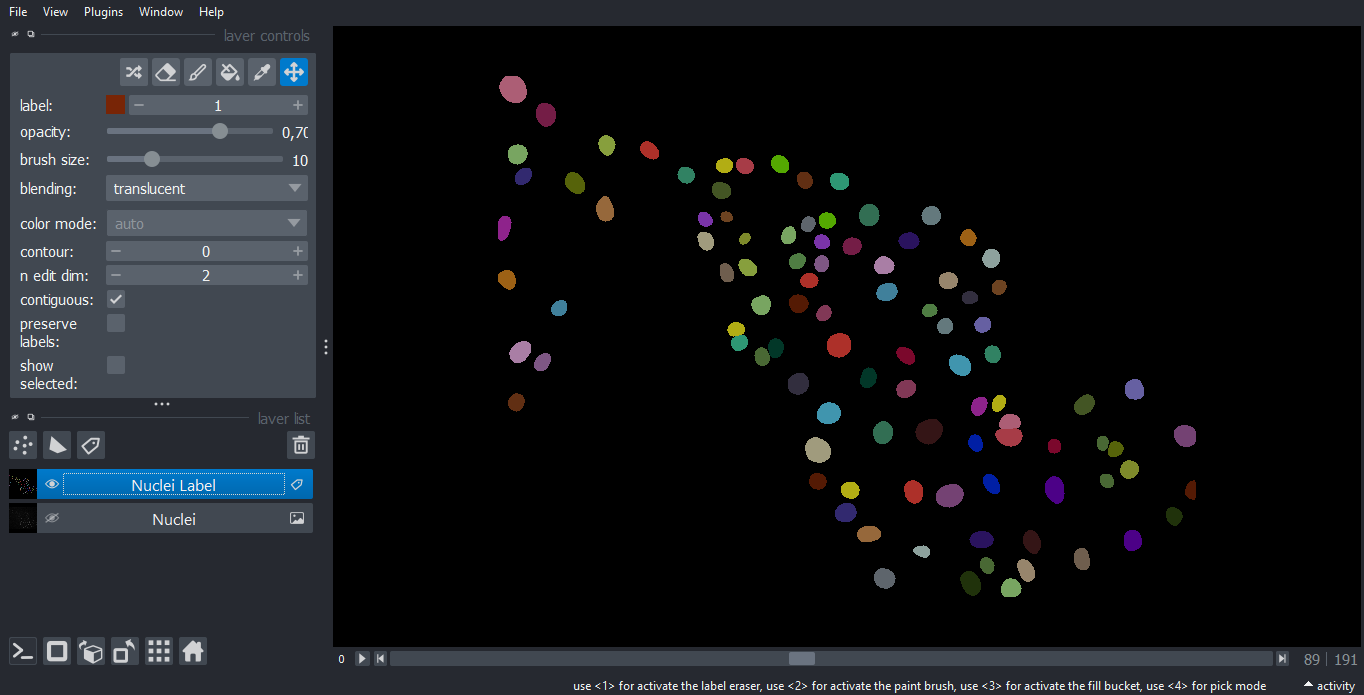



Using the Napari Viewer:

Layers (left panel):
 - Click the eye icon to show/hide layers
 - Select `Nuclei Label` to inspect segmentation
   - You can visualize label contour arround nuclei by raising `contour`

Navigation:
 - Use the bottom slider to browse images
 - Scroll in the canvas to zoom in/out

#### Converting Label Images from 32-bit to 16-bit

StarDist generates 32-bit label images by default. To reduce file size and storage requirements, we convert them to 16-bit format without loss of label information.

> **Note:** 16-bit images support up to 65,535 unique labels per image, which is more than sufficient for typical microscope field of view.

**No actions required below.**

In [ ]:
# Storing label files alphabetically in a variable
label_files = np.sort(glob.glob('label_folder/*.tiff'))
label_files

In [ ]:
# Converting 32-bit to 16-bit
for i in label_files:
    img_32bit = imread(i)
    img_16bit = img_32bit.astype(np.uint16)
    imsave(i, img_16bit)

---

## 4.Generation of Derived Labels

To measure reporters' activity, we calculate mean fluorescence intensity in the nucleus and cytoplasm. This requires:
- A nuclear label (for nuclear measurements)
- A cytoplasmic ring label (for cytoplasmic measurements)

Before performing morphological operations, we need to ensure we have all output folders (to store each type of new mask) and parameters established. 

#### Preparing folders

Output folders:
- `nucleus_eroded_tiff/` - Stores nuclear labels with eroded boundaries
- `cytoplasm_ring_tiff/` - Stores cytoplasmic ring labels

**No actions are required below.**

In [ ]:
# Storing label files alphabetically in a variable
label_files = np.sort(glob.glob('label_folder/*.tiff'))
label_files

In [ ]:
# Creating output folders for each type of new mask 
!mkdir nucleus_eroded_tiff
!mkdir cytoplasm_ring_tiff

#Saving output folders in variables
output_folder1 = 'nucleus_eroded_tiff/'
output_folder2 = 'cytoplasm_ring_tiff/'


#### Configuring Parameters

**Morphological parameters (values in pixels):**
- **Expansion radius (`radius_cyto`):** Defines how many pixels to expand outward from the edge of each nucleus to create a cellular region (default=8).
- **Dilation radius (`radius_dilated`):** Defines a slight dilation of nuclear labels to establish where the cytoplasm mask starts (default=2).
- **Nuclear erosion:** Using `morphology.disk(1)`, we shrink each nuclear label by approximately 1 pixel around its perimeter to remove potentially inaccurate edge pixels.

> **Note:** Dilation and expansion radius can be adjusted in the code below to change cytoplasmic region size.

In [ ]:
# Parameters: 
radius_cyto = 8 
radius_dilated_nucleus = 2 
selem = morphology.disk(1)  # Selem = structuring element (for erosion)

#### Performin Morphological Operations


**Cytoplasmic ring generation:**

We create the cytoplasmic ring through sequential morphological operations:

1. Nuclear expansion
   - Expand nuclear labels by `radius_cyto`
   - Result: `cyto_label` - includes nucleus and surrounding cytoplasm

> 

2. Nuclear dilation  
   - Dilate nuclear labels by `radius_dilated_nucleus`
   - Result: `dilated_nuclear_label` - a slightly enlarged nuclear region

> 

3. Cytoplasmic ring generation
   - Subtract dilated nucleus from expanded cellular region
   - Formula: `cytoplasm_ring = cyto_label - dilated_nuclear_label`
   - Result: Ring-shaped mask containing only pixels from cytoplasm region



**Nuclear erosion:**

To perform erosion, we use the fucntion `morphology.erosion` with the structuring element (selem) defined above (`morpholgy.disk(1)`). 
Nuclear edges are eroded do ensure realiable nuclear measurements.

**No actions are required below.**

> **Note:** The cell below may take a while to run. As long as you see `[*]` in the notebook cell brackets and "Processing image..." messages, the operations are running successfully.

In [ ]:
# Performing morphological operations:
for img_path in label_files:
    print("Processing image:", img_path)
    nuclear_label = imread(img_path)
    
    # Performing a morphological expansion on nuclear_label
    cyto_label = cle.dilate_labels(nuclear_label, radius=radius_cyto)
    # Performing a morphological dilation on nuclear_label
    dilated_nuclear_label = cle.dilate_labels(nuclear_label, radius=radius_dilated_nucleus)
    # Perofrming a mask subtraction 
    cytoplasm_ring = cyto_label - dilated_nuclear_label  # Use 'nuclear_label' for subtraction
    
    # Performing a morphological erosion on nuclear_label
    nucleus_eroded = morphology.erosion(nuclear_label, selem)
  
    # Saving new masks 
    basename = os.path.basename(img_path)
    new_base_eroded = basename.replace("nuclei_", "eroded_")
    new_base_ring   = basename.replace("nuclei_", "ring_")
    imsave(os.path.join(output_folder1, new_base_eroded), nucleus_eroded.astype(int))
    imsave(os.path.join(output_folder2, new_base_ring), cytoplasm_ring.astype(int))

> **Note:** You can verify if the code ran successfully by checking the output above or by manually inspecting the created folder in your file explorer.

#### Visualizing Generated Masks 

We can use Napari again to visualize the generated masks overlaid on the raw images.

The code below displays:
- Nuclei, CDK2, and CDK4 channels
- Cytoplasmic ring and eroded nucleus masks

**No actions are required below.**


In [ ]:
# Storing paths to raw images and new masks images in variables
raw_images_path = Path('separate_channels_tiff/')
cyto_dataset_path = Path('cytoplasm_ring_tiff/')
nucleus_eroded_dataset_path = Path('nucleus_eroded_tiff/')

# Running Napari
viewer = napari.Viewer()
viewer.window.resize(1800, 1000)
viewer.open(sorted(raw_images_path.glob("nuclei*.tiff")), stack=True)
viewer.open(sorted(raw_images_path.glob("cdk2*.tiff")), stack=True)  
viewer.open(sorted(raw_images_path.glob("cdk4*.tiff")), stack=True)
viewer.open(sorted(cyto_dataset_path.glob("ring*.tiff")), stack=True)
viewer.open(sorted(nucleus_eroded_dataset_path.glob("eroded*.tiff")), stack=True)

---

## 5. Properties Extraction and Calculation


By extracting and calculating properties, we will store this data in dataframes (df). In order to do so in an organized way, we must retrieve and stores file information about conditions and replicates. 

In [ ]:
# Storing separate channels tiff paths and masks paths alphabetically in variables
tiff_files_nuclei = np.sort(glob.glob('separate_channels_tiff/nuclei*.tiff'))
tiff_files_cdk2 = np.sort(glob.glob('separate_channels_tiff/cdk2*.tiff')) 
tiff_files_cdk4 = np.sort(glob.glob('separate_channels_tiff/cdk4*.tiff'))
nuclear_label_files = np.sort(glob.glob('label_folder/nuclei*.tiff'))
nucleus_eroded_files = np.sort(glob.glob('nucleus_eroded_tiff/eroded*.tiff'))
cytoplasm_ring_files = np.sort(glob.glob('cytoplasm_ring_tiff/ring*.tiff'))


#### Defining Properties and Storage

The code below defines which properties to extract and creates lists to store the results. 
These results will be stored in DataFrames, which will be exported as CSV files later. 


**Nuclear properties** (`properties_nucleus`):
- Since we have nuclear labels from StarDist segmentation, we can extract morphological properties such as area and eccentricity. While these aren't necessary for calculating Cdk2 and Cdk4 activity, they provide useful data and will be stored in a separate DataFrame specifically for nuclei.

**Intensity properties** (`properties_intensity`):
To measure Cdk2 and Cdk4 activity, we need to calculate mean fluorescence intensity in `tiff_files_cdk2` and `tiff_files_cdk4` using:
- Eroded nucleus masks (`nucleus_eroded_files`)
- Cytoplasmic ring masks (`cytoplasm_ring_files`)


**No actions are required below.**

In [ ]:
# Parameters to measure with properties
properties_nucleus = ['label', 'area', 'eccentricity', 'axis_major_length', 'axis_minor_length', 'feret_diameter_max', 'mean_intensity']  
properties_intensity = ['label', 'mean_intensity']  

#### Extracting properties

First, we load nuclei, cdk2 and cdk4 separate channels and nuclear_label, nucleus_eroded and cytoplasm_ring masks. 
Then, we can perform all measurements and convert the output (a dictionary) into pandas DataFrames. 



#### Retrieving file information

The code below also retrieves file information about conditions and replicates.
To do so, we will use `re.findall()` function and regular expressions, a way to identify patterns in strings - in this case, filenames.

ATTENTION! The regular rexpression code to retrieve file information below works for Windows which uses backslash (\) to split directories.
Mac and Linux users should adapt their code to 





Our example filename is: "nuclei_A_1_12.tiff". 

The structure of that name is:

> nuclei_<span style="color:red">Condition_Replicate_ImageNumber</span>\.tiff

> something_something_something_something.tiff

We are interested in retrieving condition , replicate and image number information.


To use the re.findall (  ) function, we follow these steps:
- Write your filename pattern, replacing each **"something"** with `.*`
- Keep underscores (_) as separators
- Add a `r` before the string
- Write the pattern between quotes: `'pattern'`

Skip the dot before .tiff → \\.tiff 

So our pattern will look like this:

```python
r'.*_.*_.*_.*\.tiff'
```

To extract a specific part of the filename (for example, CONDITION), we enclose that part of the pattern in parentheses `( )`: 
```python
r'.*_(.*)_.*_.*\.tiff'
```

To add these information in our DataFrames, we use the following sintaxe:abs 
```python
df_name['column_name'] = re.findall(filename_regular_expressions),tiff_files_nuclei[img].split('/')[-1] [0]
```

Example:
```python
df_results_nucleus_cdk2['condition'] = re.findall(r'.*_(.*)_.*_.*\.tiff', tiff_files_nuclei[img].split('/')[-1])[0]
```

> **Note:** If you are using a different pattern, you must adapt the code below according to your filenames pattern and the sintaxe above.

**Action required!:** Adapt the code below according to your filenames pattern. 

The code above created five differente DataFrames, with data from all images. However, we still have not measured Cdk2 and Cdk4 activity. 

> **Note:** You can inspect the created DataFrames by running the cells below.

In [ ]:
'''The code for retrieving file information about conditions and replicates was based
on #https://github.com/guiwitz/neubias_academy_biapy/blob/master/16-Experiment_analysis.ipynb
#BSD 3-Clause License Copyright (c) 2021, 
University of Bern, Mathematical Institute and Microscopy Imaging Center, Guillaume Witz'''
# Lists to contain the dataframes with the results
results_nucleus=[]
results_cdk2_nucleus= []  
results_cdk4_nucleus=[]
results_cdk2_cyto=[]
results_cdk4_cyto=[]

# Loading 6 differente files (separate channels and masks) correspondig to the same field of view for each image
for img in range(len(cytoplasm_ring_files)):
    cytoplasm_ring = imread(cytoplasm_ring_files[img])
    nucleus_eroded = imread(nucleus_eroded_files[img])
    nuclei = imread(tiff_files_nuclei[img])
    nuclear_label = imread(nuclear_label_files[img])
    cdk2 = imread(tiff_files_cdk2[img])
    cdk4 = imread(tiff_files_cdk4[img])
    print("Processing image:", img)   
    
    # Performing nuclear measurements
    nucleus_data = measure.regionprops_table(nuclear_label, intensity_image=nuclei, properties=properties_nucleus)
    # Performing cdk2 and cdk4 nucleus_eroded measurements
    nucleus_cdk2_data = measure.regionprops_table(nucleus_eroded, intensity_image=cdk2, properties=properties_intensity)
    nucleus_cdk4_data = measure.regionprops_table(nucleus_eroded, intensity_image=cdk4, properties=properties_intensity)
    # Performing cdk2 and cdk4 cytoplasm_ring measurements
    cyto_cdk2_data = measure.regionprops_table(cytoplasm_ring, intensity_image=cdk2, properties=properties_intensity)
    cyto_cdk4_data = measure.regionprops_table(cytoplasm_ring, intensity_image=cdk4, properties=properties_intensity)
    
    # Converting skimage.measure.regionprops_table output (a dictionary) into pandas DataFrame
    df_results_nuclei = pd.DataFrame(nucleus_data)
    df_results_nucleus_cdk2 = pd.DataFrame(nucleus_cdk2_data)
    df_results_nucleus_cdk4 = pd.DataFrame(nucleus_cdk4_data)
    df_results_cyto_cdk2 = pd.DataFrame(cyto_cdk2_data)
    df_results_cyto_cdk4 = pd.DataFrame(cyto_cdk4_data)

#     '''We need to get the ids of each image. Get this info from the file names. 
#     Get the replicate (rep1, rep2, etc)  and get conditions (control or treated, for example)'''

    # Adding columns with file informations in df_results_nucleus_cdk2
    df_results_nucleus_cdk2['filename'] = tiff_files_nuclei[img].split('\\')[-1]
    df_results_nucleus_cdk2['condition'] = re.findall(r'.*_(.*)_.*_.*\.tiff', tiff_files_nuclei[img].split('/')[-1])[0]
    df_results_nucleus_cdk2['replicate'] = re.findall(r'.*_.*_(.*)_.*\.tiff', tiff_files_nuclei[img].split('/')[-1])[0] 
    df_results_nucleus_cdk2['image_number'] = re.findall(r'.*_.*_.*_(.*)\.tiff', tiff_files_nuclei[img].split('/')[-1])[0]
    
    
    # Storing all images' DataFrames in a list 
    results_nucleus.append(df_results_nuclei)
    results_cdk2_nucleus.append(df_results_nucleus_cdk2)
    results_cdk4_nucleus.append(df_results_nucleus_cdk4)
    results_cdk2_cyto.append(df_results_cyto_cdk2)
    results_cdk4_cyto.append(df_results_cyto_cdk4)
    
    

# Concatenates all images' DataFrames in onde DataFrame for each type of results
df_results_nuclei = pd.concat([df.reset_index(drop=True) for df in results_nucleus], ignore_index=True)
df_results_nucleus_cdk2 = pd.concat([df.reset_index(drop=True) for df in results_cdk2_nucleus], ignore_index=True)
df_results_nucleus_cdk4 = pd.concat([df.reset_index(drop=True) for df in results_cdk4_nucleus], ignore_index=True)
df_results_cyto_cdk2 = pd.concat([df.reset_index(drop=True) for df in results_cdk2_cyto], ignore_index=True)
df_results_cyto_cdk4 = pd.concat([df.reset_index(drop=True) for df in results_cdk4_cyto], ignore_index=True)


In [ ]:
# DataFrame with nuclear properties
df_results_nuclei

In [ ]:
# DataFrame with nuclear mean intensity in cdk2 channel 
# DataFrame with file information retrieved
df_results_nucleus_cdk2

In [ ]:
# DataFrame with nuclear mean intensity in cdk4 channel 
df_results_nucleus_cdk4

In [ ]:
# DataFrame with cytoplasmic ring mean intensity in cdk2 channel 
df_results_cyto_cdk2

In [ ]:
# DataFrame with cytoplasmic ring mean intensity in cdk4 channel 
df_results_cyto_cdk4

We can already export `df_results_nuclei` as a CSV file (saved as `results_nuclei_properties.csv`):

In [ ]:
# Saving df_results_nuclei as a CSV file in your directory
pd.DataFrame.to_csv(df_results_nuclei, 'results_nuclei_properties.csv')

#### Calculating Cytoplasm/Nuclear Ratios for Cdk's Reporters

Now that we have all data from all images, we can calculate Cdk2 and Cdk4 activities. 
>

First, we calculate the cytoplasm/nuclear ratio for both reporters' `mean_intensity` and store the results in our DataFrames. We can calculate ratio using columns from different DataFrames and combine them into a single DataFrame containing both Cdk2 and Cdk4 cytoplasm/nuclear ratios for all cells.

> **Note:** We use `df_results_nucleus_cdk2` to consolidate all data. This is also the DataFrame that we added columns with filename, treatment, medium, replicate and image number. 

**No actions are required below!**

In [ ]:
# Calculating Cdk2 cytoplasm/nuclear ratio and storing it in df_results_nucleus_cdk2
df_results_nucleus_cdk2['cdk2_cyto_nuc_ratio'] = df_results_cyto_cdk2['mean_intensity'] / df_results_nucleus_cdk2['mean_intensity']

# Calculating Cdk4 cytoplasm/nuclear ratio and storing it in df_results_nucleus_cdk2
df_results_nucleus_cdk2['cdk4_cyto_nuc_ratio'] = df_results_cyto_cdk4['mean_intensity'] / df_results_nucleus_cdk4['mean_intensity']

# Visualizing df_results_nucleus_cdk2
df_results_nucleus_cdk2

>**Note:** By running the code above, the output DataFrame will contain both calculated ratios: `cdk2_cyto_nuc_ratio` and `cdk4_cyto_nuc_ratio`.

#### Calculating Cdk2 and Cdk4 Activities


**Cdk2 activity:**  
Directly corresponds to its reporter's cytoplasm/nuclear ratio(`cdk2_cyto_nuc_ratio`):
```
Cdk2 activity = cdk2_cyto_nuc_ratio
```


**CDK4 activity:**  
Requires correction with CDK2. As mentioned above, the CDK4 reporter (mCherry-KTR) responds partially to CDK2 activity, so we must apply a correction factor on `cdk4_cyto_nuc_ratio`
```
CDK4 activity = cdk4_cyto_nuc_ratio - 0.35 × cdk2_cyto_nuc_ratio
```


**No actions are required below.**

In [ ]:
# Adding a column for Cdk2 activity (same values as cdk2_cyto_nuc_ratio)
df_results_nucleus_cdk2["cdk2_activity"] = df_results_nucleus_cdk2['cdk2_cyto_nuc_ratio']

In [ ]:
# Apllying the correction factor for Cdk4 activity
df_results_nucleus_cdk2["cdk4_activity"] = df_results_nucleus_cdk2['cdk4_cyto_nuc_ratio'] - 0.35 * df_results_nucleus_cdk2['cdk2_cyto_nuc_ratio']

> **Note:** Run the cell below to visualize `df_results_nucleus_cdk2` and verify the calculated `cdk2_activity` and `cdk4_activity` columns.

In [ ]:
df_results_nucleus_cdk2

To save the results, we export our DataFrame as a CSV file (saved as `results_Cdk_activity_quantification.csv`):

In [ ]:
pd.DataFrame.to_csv(df_results_nucleus_cdk2, 'results_Cdk_activity_quantification.csv')

---

## 6. Plotting

Now that your data are organized in DataFrames and saved as CSV files, you can visualize **Cdk2** and **Cdk4** activities across different experimental conditions.  

In this notebook, we use two plot types (from the Seaborn library):
- **Violin plot** - Displays the full distribution of data
- **Swarm plot** - Shows individual data points overlaid on the distribution

> **Note:** At the end of this section, you will find a **Customizing Plots** guide covering plot types, color palettes, figure size and more, so don't worry if your figures don't look exactly the way you want just yet. You can skip the saving cells and come back to them once you are satisfied with your results.

### Loading Your Data
Load your CSV file into a DataFrame:

**No actions are required below** (if your csv file is named `results_Cdk_activity_quantification.csv`)

In [ ]:
# Loading your .csv file into a DataFrame
df_results = pd.read_csv('results_Cdk_activity_quantification.csv')

### Condition Labels (Optional)

Before plotting, you can map condition identifiers to descriptive names by filling in the `CONDITION_LABELS` dictionary below.

If you leave it empty (`{}`), the original values from the `condition` column will be used on the x-axis.

**Example:** In our dataset, conditions are identified as A–F, corresponding to: Low Density, High Density, Control (DMSO), Cdk2 inhibitor III, Palbociclib, and Cdk2i III + Palbo.
```python
CONDITION_LABELS = {
    'A': 'Low Density',
    'B': 'High Density',
    'C': 'Control (DMSO)',
    'D': 'Cdk2 inhibitor III',
    'E': 'Palbociclib',
    'F': 'Cdk2i III + Palbo',
}
```

**Action required!:** Fill in `CONDITION_LABELS` with your condition identifiers and descriptive names, or leave it empty (`{}`) to use the original values from the `condition` column.

In [ ]:
# Optional: mapping of condition values to descriptive names
# Leave empty ({}) to use values from df 
CONDITION_LABELS = {}

# Creating a copy of df_results replacing condition labels
df_plot = df_results.copy()
df_plot['condition'] = df_plot['condition'].replace(CONDITION_LABELS)

### Violin Plot

Violin plots are useful for visualizing the full distribution of data, as they are constructed using all individual values and their corresponding probability density.

To visualize **Cdk2 activity** for each condition, we set:
- **x-axis** as your experimental conditions (`condition`),   
- **y-axis** as the Cdk2 activity (`cdk2_activity`).  

>**Note:** Make sure these names match your DataFrame’s column names.

**No actions are required below!**

In [ ]:
# Visualizing Cdk2 Activity - Violinplot

# Setting figure size
plt.figure(figsize=(12, 6))

# Setting x and y-axis according to your df columns and color palette
sns.violinplot(x="condition", y="cdk2_activity", data=df_plot, palette="colorblind", hue="replicate")

# Setting title
plt.title("Cdk2 Activity")

# Rotating x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')

# Setting axis label 
plt.xlabel("Condition")
plt.ylabel("Cdk2 Activity")

# Setting y-axis limits 
plt.ylim(0, 5)

# Adjusting layout to prevent labels from being cut off
plt.tight_layout()

Now you can save your figure! It will be saved as a PNG file entitled `cdk2_activity_violinplot.png`.

**No actions are required below!**

In [ ]:
# Saving figure
plt.savefig("cdk2_activity_violinplot.png", dpi=300, bbox_inches="tight")

Similarly, to visualize **Cdk4 activity** we set the y-axis to the Cdk4 activity column (`cdk4_activity`). 

We also save the figure as a png file, entitled `cdk4_activity_violinplot.png`.

**No actions are required below!**

In [ ]:
# Visualizing Cdk4 Activity - Violinplot

# Setting figure size
plt.figure(figsize=(12, 6))

# Setting x and y-axis according to your df columns and color palette
sns.violinplot(x="condition", y="cdk4_activity", data=df_plot, palette="colorblind", hue="replicate")

# Setting title
plt.title("Cdk4 Activity")

# Rotating x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')

# Setting axis label 
plt.xlabel("Condition")
plt.ylabel("Cdk4 Activity")

# Setting y-axis limits 
plt.ylim(0, 4)

# Adjusting layout to prevent labels from being cut off
plt.tight_layout()

In [ ]:
# Saving figure
plt.savefig("cdk4_activity_violinplot.png", dpi=300, bbox_inches="tight")

### Swarm Plots

Swarm plots are useful for visualizing individual data points across experimental conditions, arranged to prevent overlap. In this notebook, we additionally overlay the **mean value for each replicate** as larger points.

Since fluorescence microscopy datasets can contain thousands of data points per condition, we downsample the data before plotting to keep the visualization readable while preserving the overall distribution.  

The downsampling strategy (applied independently for each Cdk activity) is based on:

- **Rice's formula**: determines the number of bins based on the sample size (`n_bins = 2 × n^(1/3)`), adapting automatically to each condition.
- **Bin sampling**: the data range is divided into equal-width bins, and a fraction (`frac`) of points is sampled from each bin. 


First, we remove any "Not A Number" (NaN) values from your DataFrame (this step is applied simultaneously to both Cdk2 and Cdk4 activity measurements).

**No actions are required below!**

In [ ]:
# Removing NaN
df_clean = df_plot.dropna(subset=['cdk2_activity', 'cdk4_activity']) 

# Verifying how many values were removed
print(f"Original DataFrame: {len(df_plot)} lines")
print(f"Cleaned DataFrame: {len(df_clean)} lines")
print(f"Removed: {len(df_plot) - len(df_clean)} lines")

#### Cdk2 Activity

Then, we need to define three parameters:

- **`condition_col`** - the column containing your conditions
- **`value_col`** - the column containing the values to be sampled (Cdk2 or Cdk4 activity)
- **`frac`** - the fraction of points sampled from each bin 

Since only one `value_col` can be used at a time, downsampling is performed separately for each Cdk activity. 

**Action required!:** Adjust `frac` below to control the fraction of points sampled from each bin (default = `0.05`- 5% per bin).

> **Note:** A larger `frac` retains more detail but may slow down rendering for large datasets.

In [ ]:
# Parameters for downsampling:
condition_col = 'condition'
value_col = 'cdk2_activity'
frac = 0.05  # 5% per bin

After that, you can downsample your data. 

**No actions are required below!**

In [ ]:
# Downsampling 

result = []

for condition in df_clean[condition_col].unique():
    subset = df_clean[df_clean[condition_col] == condition].copy()
    
    # Calculating the number of bins (Rice's Formula)
    n_bins = int(np.ceil(2 * (len(subset) ** (1/3))))
    
    # Creating equal-width bins
    subset['_bin'] = pd.cut(subset[value_col], bins=n_bins, labels=False)
    
    # Sampling a fraction
    sample = subset.groupby('_bin', group_keys=False).apply(lambda x: x.sample(frac=frac, random_state=42))
    
    result.append(sample.drop('_bin', axis=1))

# Concatenating all results
df_sampled = pd.concat(result, ignore_index=True)

Now we can generate the swarmplot.

Unlike the violin plot, we overlay two elements on the same figure: individual data points and replicate means. To ensure both are displayed on the same axes, we explicitly create the figure using `fig, ax = plt.subplots()` and pass `ax` to each plot function. 

In the next cell, you can define parameters such as figure size, y-axis limits, and color palette. The plot will be generated based on these values. We recommend starting with the default values below and adjust them as needes. Additional customization options can be found in the **Customizing Plots** section at the end of this notebook.

**No actions are required below!**

In [ ]:
# Adjusting color palette, figure size and y-axis limits

# Color palette
palette = "colorblind"

# Figure dimensions
width = 15
height = 6

# Limits for y values (cdk2 activity)
ymin = 0
ymax = 5

In [ ]:
# Visualizing Cdk2 Activity - Swarmplot

# Setting visual style and palette
sns.set(style="whitegrid") # white background and ligh grid lines
sns.set_palette(palette)

# Creating figure and setting size
fig, ax = plt.subplots(figsize=(width, height))

# Calculating mean values for each replicate
ReplicateAverages = df_plot.groupby(['condition','replicate'], as_index=False).agg({'cdk2_activity': "mean"})

# Plotting representative swarm plot
sns.swarmplot(x="condition", y="cdk2_activity", hue="replicate", dodge=True, data=df_sampled, ax=ax)

# Ploting mean values for each replicate (larger points)
sns.swarmplot(x="condition", y="cdk2_activity", hue="replicate", dodge=True, size=15, edgecolor="k", linewidth=2, data=ReplicateAverages, ax=ax)

# Removing automatic legend
ax.legend_.remove()
# Creating manual legend for each replicate 
handles, labels = ax.get_legend_handles_labels()
unique_labels, unique_handles = [], []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)
ax.legend(unique_handles, unique_labels, title='Replicate')

# Defining limits for y-axes
ax.set_ylim(ymin, ymax)

# Defining x and y labels
ax.set_xlabel("Condition")
ax.set_ylabel("Cdk2 Activity")
ax.set_title("Cdk2 Activity")

# Displaying figure
plt.show()

You can save your figure by running the cell above. 

**No actions are required below!**

In [ ]:
# Saving figure
fig.savefig("cdk2_activity_swarmplot.png", dpi=300, bbox_inches="tight")

#### Cdk4 Activity

Similarly, to visualize **Cdk4 activity** the same procedure is applied.

This involves repeating the code cells above using `cdk4_activity` as the `value_col`, along with updating the corresponding plot labels and filename.

These steps are implemented in the cells below.

**No actions are required below!**

In [ ]:
# Parameters for downsampling:
condition_col = 'condition'
value_col = 'cdk4_activity' #downsampling values for Cdk4 activity
frac = 0.05  # 5% per bin

In [ ]:
# Downsampling 

result = []

for condition in df_clean[condition_col].unique():
    subset = df_clean[df_clean[condition_col] == condition].copy()
    
    # Calculating the number of bins (Rice's Formula)
    n_bins = int(np.ceil(2 * (len(subset) ** (1/3))))
    
    # Creating equal-width bins
    subset['_bin'] = pd.cut(subset[value_col], bins=n_bins, labels=False)
    
    # Sampling a fraction
    sample = subset.groupby('_bin', group_keys=False).apply(lambda x: x.sample(frac=frac, random_state=42))
    
    result.append(sample.drop('_bin', axis=1))

# Concatenating all results
df_sampled = pd.concat(result, ignore_index=True)

In [ ]:
# Defining parameters and style for plotting

# Color palette
palette = "colorblind"

# Figure dimensions
width = 15
height = 6

# Defining limits for y values (cdk activity)
ymin = 0
ymax = 2

In [ ]:
# Visualizing Cdk4 Activity - Swarmplot

# Setting visual style and palette
sns.set(style="whitegrid") # white background and ligh grid lines
sns.set_palette(palette)

# Creating figure and setting size
fig, ax = plt.subplots(figsize=(width, height))

# Calculatin mean values for each replicate
ReplicateAverages = df_plot.groupby(['condition','replicate'], as_index=False).agg({'cdk4_activity': "mean"})

# Plotting representative swarm plot
sns.swarmplot(x="condition", y="cdk4_activity", hue="replicate", dodge=True, data=df_sampled, ax=ax)

# Ploting mean values for each replicate (larger points)
sns.swarmplot(x="condition", y="cdk4_activity", hue="replicate", dodge=True, size=15, edgecolor="k", linewidth=2, data=ReplicateAverages, ax=ax)

# Removing automatic legend
ax.legend_.remove()
# Creating manual legend for each replicate 
handles, labels = ax.get_legend_handles_labels()
unique_labels, unique_handles = [], []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)
ax.legend(unique_handles, unique_labels, title='Replicate')

# Defining limits for y-axes
ax.set_ylim(ymin, ymax)

# Defining x and y labels
ax.set_xlabel("Condition")
ax.set_ylabel("Cdk4 Activity")
ax.set_title("Cdk4 Activity")

# Displaying figure
plt.show()

You can save your figure by running the cell above. 

**No actions are required below!**

In [ ]:
# Saving figure
fig.savefig("cdk4_activity_swarmplot.png", dpi=300, bbox_inches="tight")

### Customizing Plot

This section covers parameters you can adjust to personalize your visualizations.

#### Hue and Dodge

`hue` and `dodge` are optional parameters that control how data are displayed:
- `hue='replicate'`: assigns different colors for each replicate
- `dodge=True`: separates the `hue` cattegories horizontally for each condition

#### Plot Types

To visualize data differently, you can replace `sns.violinplot` with other Seaborn plot types, such as:

- `sns.boxplot`,
- `sns.stripplot`,
- `sns.pointplot`,
- `sns.barplot`,
- `sns.boxenplot`.

You can explore the [seaborn documentation](https://seaborn.pydata.org/) for a complete list of plot types and their parameters. 

#### Color Palettes

You can personalize your plots by changing the color palette. Simply replace `palette="colorblind"` with any of the options below. 

- `deep`
- `muted`
- `pastel`
- `bright`
- `dark`

> **Note:** `colorblind` was chosen as default for accessibility. 

#### Figure Size and Axis Limits

These parameters are related to the dimension of your figure and the visible range of y-axis: 

- `figsize=(width, height)`: sets the figure size in inches,
- `plt.ylim(ymin, ymax)`: sets the y-axis range - ajdust these values based on the range of your data.